# 02 — Entraînement et comparaison des modèles

Pipeline reproductible : `models/train.py` (seed 42). Ce notebook l'exécute et analyse les résultats.

Exigences du sujet couvertes : baseline simple, comparaison de 2 approches, métriques top-k
(top-1/top-3, MRR), F1 macro, calibration (ECE), matrice de confusion, stabilité, analyse d'erreurs.

In [1]:
%run ../models/train.py

baseline_majoritaire     {'top1_accuracy': 0.14, 'top3_accuracy': 0.2683, 'mrr': 0.268, 'f1_macro': 0.0154, 'ece': 0.86}
regression_logistique    {'top1_accuracy': 0.485, 'top3_accuracy': 0.8317, 'mrr': 0.6666, 'f1_macro': 0.4447, 'ece': 0.0731}
foret_aleatoire          {'top1_accuracy': 0.4317, 'top3_accuracy': 0.7233, 'mrr': 0.6123, 'f1_macro': 0.3467, 'ece': 0.1928}

Meilleur modele : regression_logistique
Stabilite du top-3 sous perturbation : 0.8178

[OK] model.joblib, metrics.json, confusion_matrix.csv, RAPPORT-ML.md -> C:\Users\LCS\Desktop\Examen Clinique\models


In [2]:
import json
import pandas as pd

metrics = json.load(open('../models/metrics.json', encoding='utf-8'))
pd.DataFrame(metrics['modeles']).T

,top1_accuracy,top3_accuracy,mrr,f1_macro,ece,stabilite_top3
baseline_majoritaire,0.1400,0.2683,0.2680,0.0154,0.8600,NaN
regression_logistique,0.4850,0.8317,0.6666,0.4447,0.0731,0.8178
foret_aleatoire,0.4317,0.7233,0.6123,0.3467,0.1928,NaN


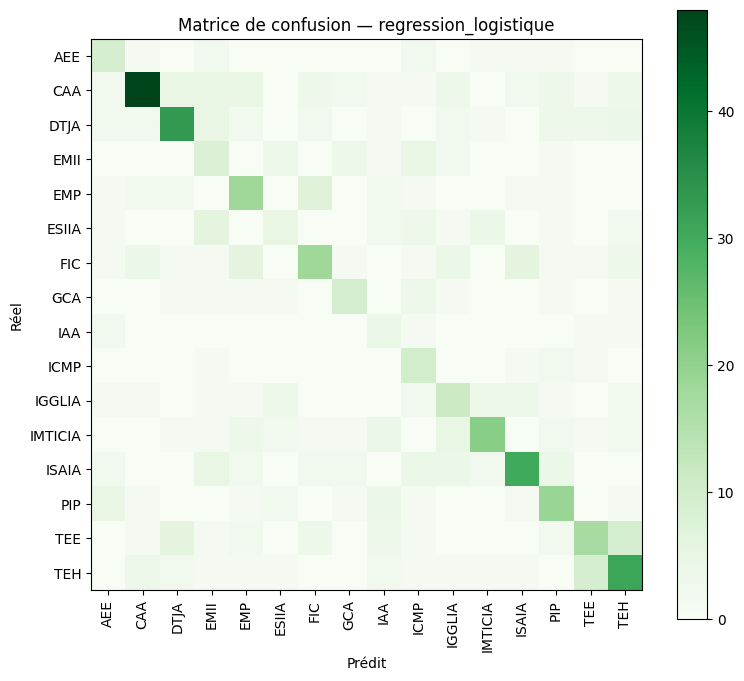

In [3]:
# Matrice de confusion du meilleur modèle : quelles filières se confondent ?
import matplotlib.pyplot as plt

cm = pd.read_csv('../models/confusion_matrix.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=90)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f"Matrice de confusion — {metrics['meilleur_modele']}")
fig.colorbar(im); plt.tight_layout(); plt.show()

In [4]:
# Variables les plus importantes + classes les plus difficiles.
print('Pires classes (F1) :', metrics['pires_classes_f1'])
pd.Series(metrics['importances_top15'], name='importance')

Pires classes (F1) : {'ESIIA': 0.2381, 'IAA': 0.2424, 'EMII': 0.2623, 'IGGLIA': 0.3492}


Series([], Name: importance, dtype: object)

## Analyse des résultats (validation interne, synthétique → synthétique)

- La **régression logistique bat la forêt aléatoire** (top-3 : 0,83 vs 0,72) : les features multi-hot
  sont quasi linéairement séparables par construction ; le modèle simple généralise mieux et se
  **calibre bien mieux** (ECE 0,07 vs 0,19) — ses probabilités sont fiables pour exprimer l'incertitude.
- Le **top-1 plafonne (~0,49)** : conséquence directe du bruit d'étiquette volontaire (tirage softmax
  à la génération). C'est un plafond irréductible connu, pas un défaut du modèle — la métrique métier
  est le top-3 (on propose 3 parcours, pas un verdict).
- **Confusions attendues** entre filières proches (ex. département Affaires entre elles) : à commenter
  cas par cas depuis la matrice de confusion.
- **Étape décisive restante** : `models/transfert_reel.py` sur les réponses d'enquête gelées —
  c'est la mesure de généralisation que le sujet valorise le plus.